# 2026-03 - Param-Eq Baseline Thesis Check

This notebook is intentionally comparison-first.

Its main claim is:
- the archived Haskell artifact,
- a fresh live Haskell rerun, and
- the retained Egglog baseline

all support the same qualitative paper conclusions on the retained param-eq
metrics.

The notebook reads only checked-in artifacts:
- archived Haskell rows
- live Haskell rows
- Egglog rows
- Pagie runtime comparison rows for all three implementations

Offline regeneration commands from the repository root:
- `uv run python -m egglog.exp.param_eq.normalize_archives`
- `uv run python -m egglog.exp.param_eq.run_haskell_corpus`
- `uv run python -m egglog.exp.param_eq.run_egglog_corpus`
- `uv run python python/egglog/exp/param_eq/replication.py`

In [1]:
from __future__ import annotations

import os
from io import StringIO
from typing import Any

import altair as alt
import jupytext
import nbformat
import pandas as pd
from IPython.display import SVG, display
from nbclient import NotebookClient

from egglog.exp.param_eq.paths import ARTIFACT_DIR, PARAM_EQ_DIR

alt.data_transformers.disable_max_rows()
alt.renderers.enable("default")

ALGORITHM_ORDER = ["Bingo", "EPLEX", "GP-GOMEA", "Operon", "PySR", "SBP"]
DATASET_ORDER = ["pagie", "kotanchek"]
DATASET_LABELS = {"pagie": "Pagie-1", "kotanchek": "Kotanchek"}
IMPLEMENTATION_ORDER = ["Archived Haskell", "Live Haskell", "Egglog"]
METHOD_ORDER = ["EqSat", "Sympy", "Sympy + EqSat"]
COMPARISON_ORDER = ["Sympy x EqSat", "Sympy + EqSat x EqSat"]
DELTA_ORDER = ["Δ == 0", "Δ <= 1"]

BOX_COLOR = "#4C78A8"
POINT_COLOR = "#F58518"
TABLE_FILL = "#F7F7F7"

ARCHIVED_HASKELL_PATH = ARTIFACT_DIR / "haskell_paper_rows.csv"
LIVE_HASKELL_PATH = ARTIFACT_DIR / "haskell_live_rows.csv"
EGGLOG_PATH = ARTIFACT_DIR / "egglog_paper_rows.csv"
RUNTIME_PATH = ARTIFACT_DIR / "pagie_runtime_compare.csv"

for required_path in [ARCHIVED_HASKELL_PATH, LIVE_HASKELL_PATH, EGGLOG_PATH, RUNTIME_PATH]:
    if not required_path.exists():
        msg = f"Missing required artifact: {required_path}"
        raise FileNotFoundError(msg)


def _coerce_numeric(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


def _paper_haskell_frame(path: os.PathLike[str] | str) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame = frame[frame["is_paper_row"] == 1].copy()
    return _coerce_numeric(
        frame,
        [
            "raw_index",
            "algo_row",
            "orig_nodes",
            "orig_params",
            "simpl_nodes",
            "simpl_params",
            "orig_runtime_ms",
            "orig_nodes_sympy",
            "orig_params_sympy",
            "simpl_nodes_sympy",
            "simpl_params_sympy",
            "sympy_runtime_ms",
            "n_params",
            "n_rank",
        ],
    )


def _paper_egglog_frame(path: os.PathLike[str] | str) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame = frame[frame["is_paper_row"] == 1].copy()
    return _coerce_numeric(
        frame,
        [
            "raw_index",
            "algo_row",
            "orig_runtime_ms",
            "orig_nodes",
            "orig_params",
            "simpl_nodes",
            "simpl_params",
            "orig_total_size",
            "orig_egraph_nodes",
            "orig_eclass_count",
            "orig_passes",
            "orig_extracted_cost",
            "sympy_runtime_ms",
            "orig_nodes_sympy",
            "orig_params_sympy",
            "simpl_nodes_sympy",
            "simpl_params_sympy",
            "sympy_total_size",
            "sympy_egraph_nodes",
            "sympy_eclass_count",
            "sympy_passes",
            "sympy_extracted_cost",
            "n_params",
            "n_rank",
        ],
    )


def _paper_runtime_frame() -> pd.DataFrame:
    frame = pd.read_csv(RUNTIME_PATH)
    return _coerce_numeric(frame, ["node_count", "runtime_ms"])


def add_paper_metrics(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["orig_x_egg"] = (result["orig_params"] - result["simpl_params"]) / result["orig_params"]
    result["orig_x_sympy"] = (result["orig_params"] - result["orig_params_sympy"]) / result["orig_params"]
    result["orig_x_sympyegg"] = (result["orig_params"] - result["simpl_params_sympy"]) / result["orig_params"]
    result["sympy_x_egg"] = (result["orig_params_sympy"] - result["simpl_params"]) / result["orig_params_sympy"]
    result["sympyegg_x_egg"] = (result["simpl_params_sympy"] - result["simpl_params"]) / result["simpl_params_sympy"]
    result["orig_rank"] = result["n_params"] - result["n_rank"]
    result["simpl_rank"] = result["simpl_params"] - result["n_rank"]
    result["sympy_rank"] = result["orig_params_sympy"] - result["n_rank"]
    return result


def with_implementation(frame: pd.DataFrame, implementation: str) -> pd.DataFrame:
    result = frame.copy()
    result["implementation"] = implementation
    result["dataset_label"] = result["dataset"].map(DATASET_LABELS)
    return result


def melt_methods(frame: pd.DataFrame, *, columns: dict[str, str], value_name: str) -> pd.DataFrame:
    melted = frame.melt(
        id_vars=["implementation", "dataset", "dataset_label", "algorithm", "raw_index"],
        value_vars=list(columns.values()),
        var_name="method_key",
        value_name=value_name,
    )
    inverse = {value: key for key, value in columns.items()}
    melted["method"] = melted["method_key"].map(inverse)
    return melted.drop(columns=["method_key"])


def _point_layer(frame: pd.DataFrame, *, y: str, tooltip: list[str]) -> alt.Chart:
    return (
        alt.Chart(frame)
        .transform_calculate(jitter="(random() - 0.5) * 18")
        .mark_circle(size=38, color=POINT_COLOR, opacity=0.68, stroke="white", strokeWidth=0.7)
        .encode(
            xOffset=alt.XOffset("jitter:Q"),
            y=alt.Y(f"{y}:Q"),
            tooltip=tooltip,
        )
    )


def faceted_boxplot(frame: pd.DataFrame, *, y: str, title: str, method_sort: list[str]) -> Any:
    base = (
        alt.Chart(frame)
        .encode(
            x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
            y=alt.Y(f"{y}:Q", title=y.replace("_", " ")),
        )
        .properties(width=115, height=170)
    )
    layered = alt.layer(
        _point_layer(
            frame,
            y=y,
            tooltip=["implementation", "dataset", "algorithm", "method", "raw_index", y],
        ).encode(x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm")),
        base.mark_boxplot(size=16, opacity=0.58, color=BOX_COLOR, outliers=False),
    )
    return layered.facet(
        row=alt.Row("implementation:N", sort=IMPLEMENTATION_ORDER, title=None),
        column=alt.Column("method:N", sort=method_sort, title=None),
    ).properties(title=title)


def rank_boxplot(frame: pd.DataFrame, *, title: str) -> Any:
    base = (
        alt.Chart(frame)
        .encode(
            x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
            y=alt.Y("simpl_rank:Q", title="simplified params - rank"),
        )
        .properties(width=115, height=170)
    )
    layered = alt.layer(
        _point_layer(
            frame,
            y="simpl_rank",
            tooltip=["implementation", "dataset", "algorithm", "raw_index", "simpl_rank", "n_rank", "simpl_params"],
        ).encode(x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm")),
        base.mark_boxplot(size=16, opacity=0.58, color=BOX_COLOR, outliers=False),
    )
    return layered.facet(
        row=alt.Row("implementation:N", sort=IMPLEMENTATION_ORDER, title=None),
        column=alt.Column("dataset_label:N", sort=[DATASET_LABELS[d] for d in DATASET_ORDER], title=None),
    ).properties(title=title)


def runtime_chart(frame: pd.DataFrame, *, title: str) -> Any:
    return (
        alt.Chart(frame)
        .mark_circle(size=70, opacity=0.78, stroke="white", strokeWidth=0.8, color=BOX_COLOR)
        .encode(
            x=alt.X("node_count:Q", title="number of nodes"),
            y=alt.Y("runtime_ms:Q", title="runtime (ms)"),
            tooltip=["implementation", "node_count", "runtime_ms"],
        )
        .properties(width=220, height=220)
        .facet(column=alt.Column("implementation:N", sort=IMPLEMENTATION_ORDER, title=None))
        .properties(title=title)
    )


def comparison_table(frame: pd.DataFrame, *, implementation: str) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for dataset in DATASET_ORDER:
        dataset_frame = frame[frame["dataset"] == dataset]
        for algorithm in ALGORITHM_ORDER:
            algo_frame = dataset_frame[dataset_frame["algorithm"] == algorithm]
            for delta in [0, 1]:
                eligible = algo_frame[algo_frame["orig_rank"] > delta]
                percent = float("nan")
                if not eligible.empty:
                    percent = 100.0 * (eligible["simpl_rank"] <= delta).sum() / len(eligible)
                rows.append({
                    "implementation": implementation,
                    "dataset": dataset,
                    "dataset_label": DATASET_LABELS[dataset],
                    "algorithm": algorithm,
                    "delta": f"Δ {'==' if delta == 0 else '<='} {delta}",
                    "percent": percent,
                })
    result = pd.DataFrame(rows)
    result["percent_label"] = result["percent"].map(lambda value: "n/a" if pd.isna(value) else f"{value:.2f}%")
    return result


def faceted_table4_chart(frame: pd.DataFrame) -> Any:
    base = alt.Chart(frame).encode(
        x=alt.X("dataset_label:N", sort=[DATASET_LABELS[d] for d in DATASET_ORDER], title=None),
        y=alt.Y("algorithm:N", sort=ALGORITHM_ORDER, title=None),
    )
    layered = alt.layer(
        base.mark_rect(fill=TABLE_FILL, stroke="#DDDDDD"),
        base.mark_text(fontSize=11).encode(text="percent_label:N"),
    ).properties(width=120, height=18 * len(ALGORITHM_ORDER))
    return layered.facet(
        row=alt.Row("delta:N", sort=DELTA_ORDER, title=None),
        column=alt.Column("implementation:N", sort=IMPLEMENTATION_ORDER, title=None),
    ).properties(title="Faceted Table 4 analog")


def show_chart(chart: Any) -> None:
    buffer = StringIO()
    chart.save(buffer, format="svg")
    display(SVG(buffer.getvalue()))


archived_haskell = with_implementation(
    add_paper_metrics(_paper_haskell_frame(ARCHIVED_HASKELL_PATH)), "Archived Haskell"
)
live_haskell = with_implementation(add_paper_metrics(_paper_haskell_frame(LIVE_HASKELL_PATH)), "Live Haskell")
egglog = with_implementation(add_paper_metrics(_paper_egglog_frame(EGGLOG_PATH)), "Egglog")
runtime_rows = _paper_runtime_frame()

combined = pd.concat([archived_haskell, live_haskell, egglog], ignore_index=True)

haskell_columns = {
    "EqSat": "orig_x_egg",
    "Sympy": "orig_x_sympy",
    "Sympy + EqSat": "orig_x_sympyegg",
}
comparison_columns = {
    "Sympy x EqSat": "sympy_x_egg",
    "Sympy + EqSat x EqSat": "sympyegg_x_egg",
}

egglog_vs_live = egglog.merge(
    live_haskell[
        [
            "dataset",
            "algorithm",
            "raw_index",
            "simpl_params",
            "simpl_params_sympy",
        ]
    ],
    on=["dataset", "algorithm", "raw_index"],
    suffixes=("_egglog", "_live"),
)
egglog_vs_live["orig_exact"] = egglog_vs_live["simpl_params_egglog"] == egglog_vs_live["simpl_params_live"]
egglog_vs_live["sympy_exact"] = egglog_vs_live["simpl_params_sympy_egglog"] == egglog_vs_live["simpl_params_sympy_live"]
egglog_vs_live["orig_gap"] = (egglog_vs_live["simpl_params_egglog"] - egglog_vs_live["simpl_params_live"]).abs()
egglog_vs_live["sympy_gap"] = (
    egglog_vs_live["simpl_params_sympy_egglog"] - egglog_vs_live["simpl_params_sympy_live"]
).abs()

archive_drift = live_haskell.merge(
    archived_haskell[
        [
            "dataset",
            "algorithm",
            "raw_index",
            "simpl_params",
            "simpl_params_sympy",
        ]
    ],
    on=["dataset", "algorithm", "raw_index"],
    suffixes=("_live", "_archived"),
)
archive_drift["orig_drift"] = archive_drift["simpl_params_live"] - archive_drift["simpl_params_archived"]
archive_drift["sympy_drift"] = archive_drift["simpl_params_sympy_live"] - archive_drift["simpl_params_sympy_archived"]

live_fallback_rows = live_haskell[live_haskell["baseline_source"] != "live_haskell"][
    ["dataset", "algorithm", "algo_row", "baseline_source", "orig_live_status", "sympy_live_status"]
].drop_duplicates()

runtime_compare = runtime_rows[["implementation", "node_count", "runtime_ms"]].copy()

table4_source = pd.concat(
    [
        comparison_table(archived_haskell, implementation="Archived Haskell"),
        comparison_table(live_haskell, implementation="Live Haskell"),
        comparison_table(egglog, implementation="Egglog"),
    ],
    ignore_index=True,
)

## 1. Artifact Overview

In [2]:
artifact_summary = pd.DataFrame([
    {
        "implementation": "Archived Haskell",
        "rows": len(archived_haskell),
        "original_median_simpl_rank": float(archived_haskell["simpl_rank"].median()),
        "sympy_median_simpl_rank": float(archived_haskell["sympy_rank"].median()),
    },
    {
        "implementation": "Live Haskell",
        "rows": len(live_haskell),
        "original_median_simpl_rank": float(live_haskell["simpl_rank"].median()),
        "sympy_median_simpl_rank": float(live_haskell["sympy_rank"].median()),
    },
    {
        "implementation": "Egglog",
        "rows": len(egglog),
        "original_median_simpl_rank": float(egglog["simpl_rank"].median()),
        "sympy_median_simpl_rank": float(egglog["sympy_rank"].median()),
    },
])
display(artifact_summary)
display(
    pd.DataFrame([
        {
            "comparison": "Egglog vs live Haskell (original)",
            "exact_matches": int(egglog_vs_live["orig_exact"].sum()),
            "total_rows": len(egglog_vs_live),
            "max_gap": int(egglog_vs_live["orig_gap"].max()),
        },
        {
            "comparison": "Egglog vs live Haskell (sympy)",
            "exact_matches": int(egglog_vs_live["sympy_exact"].sum()),
            "total_rows": len(egglog_vs_live),
            "max_gap": int(egglog_vs_live["sympy_gap"].max()),
        },
        {
            "comparison": "Live vs archived Haskell (original)",
            "exact_matches": int((archive_drift["orig_drift"] == 0).sum()),
            "total_rows": len(archive_drift),
            "max_gap": int(archive_drift["orig_drift"].abs().max()),
        },
        {
            "comparison": "Live vs archived Haskell (sympy)",
            "exact_matches": int((archive_drift["sympy_drift"] == 0).sum()),
            "total_rows": len(archive_drift),
            "max_gap": int(archive_drift["sympy_drift"].abs().max()),
        },
    ])
)
# -

,implementation,rows,original_median_simpl_rank,sympy_median_simpl_rank
0,Archived Haskell,341,0.0,3.0
1,Live Haskell,341,0.0,3.0
2,Egglog,341,0.0,2.0


,comparison,exact_matches,total_rows,max_gap
0,Egglog vs live Haskell (original),317,341,3
1,Egglog vs live Haskell (sympy),325,341,6
2,Live vs archived Haskell (original),333,341,3
3,Live vs archived Haskell (sympy),328,341,2


The retained question is no longer whether Egglog finishes the corpus; it does.

The useful question is whether the three result sets support the same practical
thesis. After correcting the live Haskell rerun to follow the checked-in
Haskell Sympy modules directly, archived and live Haskell are much closer than
they first appeared. The rest of this notebook therefore compares archived
Haskell, live Haskell, and Egglog with the same plots and the same table
layouts.

## 2. Reduction Ratios

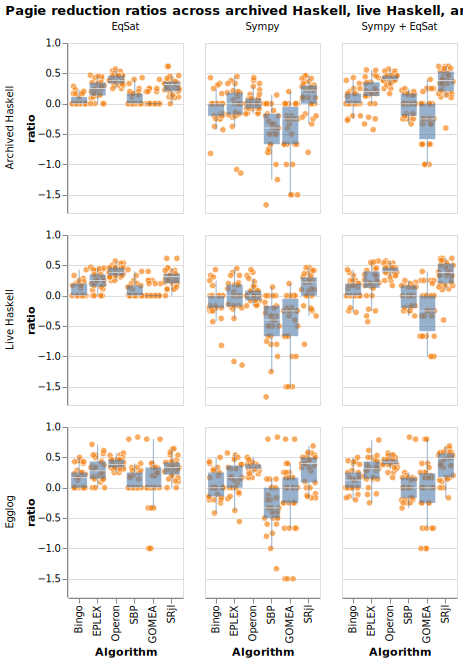

In [3]:
show_chart(
    faceted_boxplot(
        melt_methods(combined[combined["dataset"] == "pagie"], columns=haskell_columns, value_name="ratio"),
        y="ratio",
        method_sort=METHOD_ORDER,
        title="Pagie reduction ratios across archived Haskell, live Haskell, and Egglog",
    )
)

Across the Pagie rows, all three implementations preserve the same qualitative
story: EqSat helps on its own, Sympy alone is not the main source of the gain,
and the combined pipeline remains the strongest or near-strongest path. The
archived and live Haskell views are now close enough that the archive reads as
a slightly stale version of the same picture rather than a conflicting one,
and Egglog tracks that shared picture closely enough to support the same
conclusion.

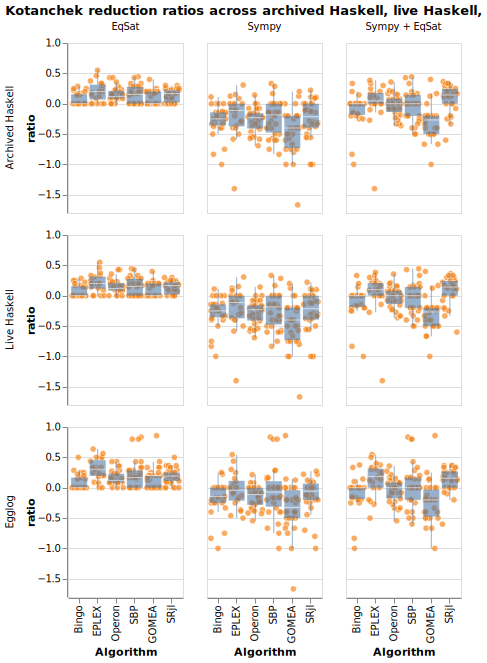

In [4]:
show_chart(
    faceted_boxplot(
        melt_methods(combined[combined["dataset"] == "kotanchek"], columns=haskell_columns, value_name="ratio"),
        y="ratio",
        method_sort=METHOD_ORDER,
        title="Kotanchek reduction ratios across archived Haskell, live Haskell, and Egglog",
    )
)

Kotanchek tells the same story. The per-algorithm spread changes a little
between the archived artifact and the live rerun, but the headline result does
not: EqSat is still the meaningful simplification step, and Egglog lands in
the same visual regime as both Haskell baselines.

## 3. EqSat Versus Sympy Comparisons

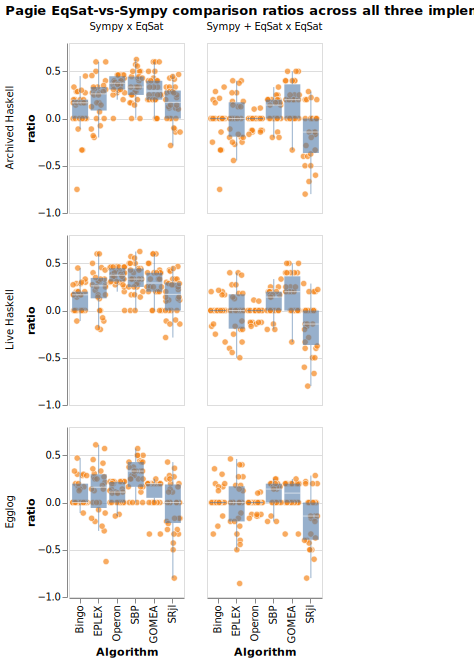

In [5]:
show_chart(
    faceted_boxplot(
        melt_methods(combined[combined["dataset"] == "pagie"], columns=comparison_columns, value_name="ratio"),
        y="ratio",
        method_sort=COMPARISON_ORDER,
        title="Pagie EqSat-vs-Sympy comparison ratios across all three implementations",
    )
)

These comparison ratios make the thesis more explicit: rerunning EqSat after
the Sympy-derived starting point still matters in all three result sets. The
archive, the live rerun, and Egglog all agree that the simplification is not
coming only from the symbolic preprocessing step.

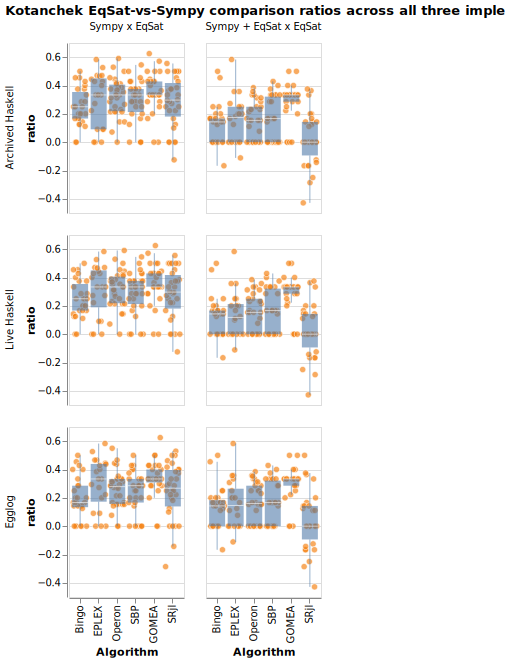

In [6]:
show_chart(
    faceted_boxplot(
        melt_methods(combined[combined["dataset"] == "kotanchek"], columns=comparison_columns, value_name="ratio"),
        y="ratio",
        method_sort=COMPARISON_ORDER,
        title="Kotanchek EqSat-vs-Sympy comparison ratios across all three implementations",
    )
)

The Kotanchek comparison view reaches the same conclusion. Even where archive
drift is visible, it is now a narrow tail instead of a broad Sympy split, and
the three implementations still agree on the sign and rough scale of the
EqSat contribution. That is the notebook's central evidence that the retained
Egglog baseline is good enough to count as hitting the paper baseline in
practice.

## 4. Rank Target And Runtime Shape

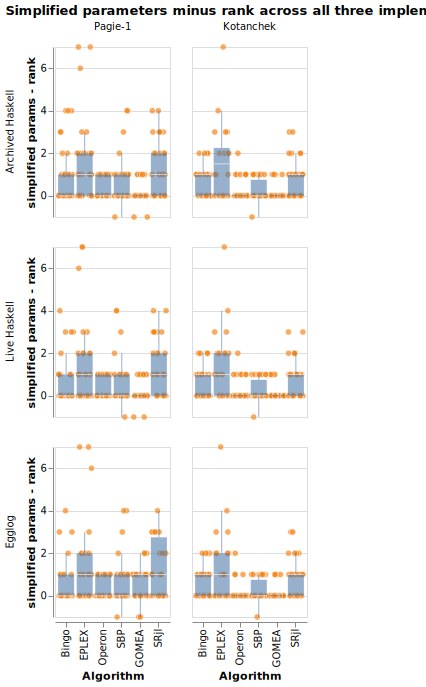

In [7]:
show_chart(rank_boxplot(combined, title="Simplified parameters minus rank across all three implementations"))

All three implementations keep the simplified expressions clustered near the
paper rank target. This is the most direct coarse-grained thesis check: the
live rerun and the Egglog replication lead to the same qualitative conclusion
as the archived paper outputs about how often the target rank is met or nearly
met.

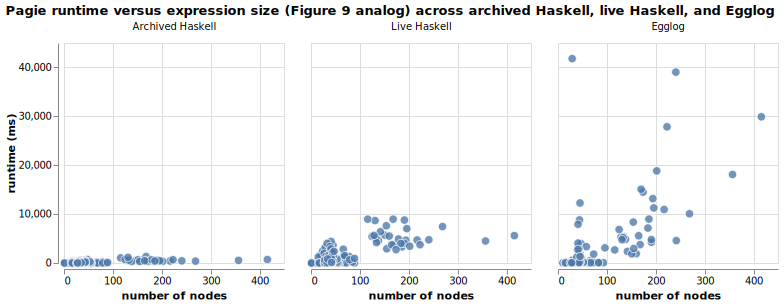

In [8]:
show_chart(
    runtime_chart(
        runtime_compare,
        title="Pagie runtime versus expression size (Figure 9 analog) across archived Haskell, live Haskell, and Egglog",
    )
)

This faceted Figure 9 analog is now closer to the archived benchmark setup:
all three facets are built from the broader Pagie original-expression sweep,
and the x-axis is the input expression node count rather than e-graph size.

With that apples-to-apples population, live Haskell and Egglog now occupy a
much more similar node-count range to the archived Haskell plot. The main
remaining difference is the runtime tail: Egglog still has noticeably slower
cases at comparable input sizes, which points more toward rewrite-search and
implementation overhead than toward a simple “Egglog starts from larger input
trees” explanation.

## 5. Faceted Table 4 Analog

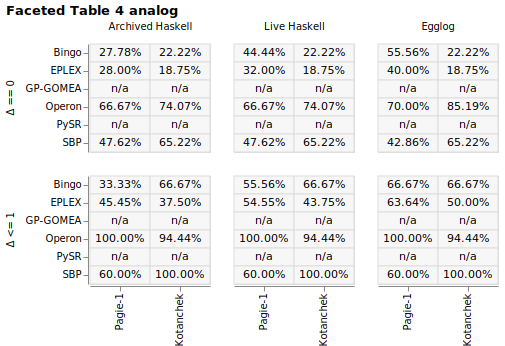

In [9]:
show_chart(faceted_table4_chart(table4_source))

The faceted Table 4 analog says the same thing as the boxplots in a paper-style
summary format. Archived Haskell, live Haskell, and Egglog differ row by row,
but they preserve the same practical ordering of algorithms and the same
overall conclusion about how often EqSat reaches the target rank or stays
within one extra parameter. The biggest archived-versus-live shifts are now
concentrated in a small Pagie Bingo and Pagie EPLEX tail rather than spread
across the whole table.

## 6. Archive Drift

In [10]:
display(
    archive_drift[
        [
            "dataset",
            "algorithm",
            "algo_row",
            "orig_drift",
            "sympy_drift",
            "simpl_params_live",
            "simpl_params_archived",
            "simpl_params_sympy_live",
            "simpl_params_sympy_archived",
        ]
    ]
    .sort_values(["orig_drift", "sympy_drift"], key=lambda column: column.abs(), ascending=False)
    .head(12)
)

,dataset,algorithm,algo_row,orig_drift,sympy_drift,simpl_params_live,simpl_params_archived,simpl_params_sympy_live,simpl_params_sympy_archived
19,pagie,Bingo,21,-3.0,0.0,4.0,7.0,4.0,4.0
30,pagie,EPLEX,5,-2.0,-2.0,11.0,13.0,11.0,13.0
203,kotanchek,EPLEX,4,-2.0,-2.0,8.0,10.0,8.0,10.0
3,pagie,Bingo,4,-2.0,0.0,6.0,8.0,6.0,6.0
0,pagie,Bingo,1,-1.0,-2.0,7.0,8.0,6.0,8.0
6,pagie,Bingo,7,-1.0,-1.0,4.0,5.0,4.0,5.0
47,pagie,EPLEX,23,-1.0,-1.0,4.0,5.0,3.0,4.0
23,pagie,Bingo,25,-1.0,0.0,3.0,4.0,3.0,3.0
8,pagie,Bingo,9,0.0,-1.0,5.0,5.0,6.0,7.0
9,pagie,Bingo,10,0.0,-1.0,4.0,4.0,5.0,6.0


Archive drift is real, but after correcting the live rerun to use the actual
checked-in Haskell Sympy modules it is much smaller than the earlier draft of
this notebook suggested. The remaining drift is a short tail, mostly in Pagie
Bingo and Pagie EPLEX Sympy rows plus a few EPLEX rows on Kotanchek. That is
enough to justify reporting the live rerun separately, but not enough to
overturn the main thesis of the paper figures: the archived artifact and the
live rerun still support the same qualitative story, and Egglog remains close
enough to the live rerun to support that same story too.

### Live-Haskell fallback rows

In [11]:
display(live_fallback_rows if not live_fallback_rows.empty else pd.DataFrame([{"status": "none"}]))

,dataset,algorithm,algo_row,baseline_source,orig_live_status,sympy_live_status
14,pagie,Bingo,15,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
15,pagie,Bingo,16,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
22,pagie,Bingo,24,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
25,pagie,Bingo,27,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
40,pagie,EPLEX,16,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
42,pagie,EPLEX,18,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
44,pagie,EPLEX,20,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
49,pagie,EPLEX,25,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
205,kotanchek,EPLEX,8,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
212,kotanchek,EPLEX,19,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow


## 7. Conclusion

Archived Haskell, live Haskell, and Egglog all support the same qualitative
paper conclusion on the retained param-eq metrics.

The remaining Egglog-versus-live differences are a small row-level tail rather
than a broad failure mode, and the archived-versus-live Haskell differences
are now modest enough to read as archive drift rather than a contradictory
result set.

Taken together, these plots support the retained thesis: the Egglog baseline
behaves close enough to both Haskell baselines that it reproduces the paper's
practical conclusions, while the remaining archive drift is a caveat that
sharpens interpretation rather than evidence of a replication failure.

In [12]:
def _write_executed_notebook() -> None:
    source_path = PARAM_EQ_DIR / "replication.py"
    output_path = source_path.with_suffix(".ipynb")
    notebook = jupytext.read(source_path, fmt="py:light")
    previous = os.environ.get("EGGLOG_PARAM_EQ_SYNC_IPYNB")
    os.environ["EGGLOG_PARAM_EQ_SYNC_IPYNB"] = "0"
    try:
        executed = NotebookClient(notebook, timeout=600, kernel_name="python3").execute()
    finally:
        if previous is None:
            os.environ.pop("EGGLOG_PARAM_EQ_SYNC_IPYNB", None)
        else:
            os.environ["EGGLOG_PARAM_EQ_SYNC_IPYNB"] = previous
    with output_path.open("w", encoding="utf-8") as handle:
        nbformat.write(executed, handle)

In [13]:
if __name__ == "__main__" and os.environ.get("EGGLOG_PARAM_EQ_SYNC_IPYNB", "1") != "0":
    _write_executed_notebook()